# DDM Model Compilation and Testing Workflow

This notebook provides step-by-step instructions for compiling and testing the DDM (Drift Diffusion Model) JAGS module.


## Prerequisites

Ensure you have the required dependencies installed:
- JAGS 4.3.0+
- ONNX Runtime 1.23.2+ (Linux x64)
- py2jags 0.1.0+
- Python 3.11+ with scikit-learn


In [11]:
# Naming from metadata
from jnnx import JNNXPackage
_pkg = JNNXPackage('/home/jovyan/project/models/ddm.jnnx')
MODULE_NAME = _pkg.metadata['module_name']
FUNCTION_NAME = _pkg.metadata['function_name']
print('Using module/function:', MODULE_NAME, FUNCTION_NAME)


Using module/function: ddm_emulator ddm_emulator


## Step 1: Generate Module Code


In [12]:
from jnnx import JNNXPackage, JAGSModule

# Generate module code using Python API
pkg = JNNXPackage('/home/jovyan/project/models/ddm.jnnx')
module = JAGSModule(pkg, 'tmp/ddm.jnnx_build')
module.generate_code()
print('Module code generated in tmp/ddm.jnnx_build')


Copied external data file to tmp/ddm.jnnx_build/model.onnx.data
Module code generated in tmp/ddm.jnnx_build


In [13]:
# Ensure ONNX Runtime is available at expected path for compilation
import os, tarfile, urllib.request
from pathlib import Path

onnx_dir = Path('/home/jovyan/project/tmp/onnxruntime-linux-x64-1.23.2')
if not onnx_dir.exists():
    onnx_dir.parent.mkdir(parents=True, exist_ok=True)
    url = 'https://github.com/microsoft/onnxruntime/releases/download/v1.23.2/onnxruntime-linux-x64-1.23.2.tgz'
    tgz_path = onnx_dir.parent / 'onnxruntime-linux-x64-1.23.2.tgz'
    print('Downloading ONNX Runtime...', url)
    urllib.request.urlretrieve(url, tgz_path)
    print('Extracting...', tgz_path)
    with tarfile.open(tgz_path, 'r:gz') as tf:
        tf.extractall(path=onnx_dir.parent)
    print('ONNX Runtime ready at', onnx_dir)
else:
    print('ONNX Runtime already present at', onnx_dir)


ONNX Runtime already present at /home/jovyan/project/tmp/onnxruntime-linux-x64-1.23.2


## Step 2: Compile the Module


In [14]:
# Compile using Python API
success, msg = module.compile()
if not success:
    raise RuntimeError(msg)
print('Compilation succeeded')


Compilation succeeded


In [15]:
# Install using Python API
success, msg = module.install()
if not success:
    raise RuntimeError(msg)
print('Installation succeeded')


Installation succeeded


## Step 3: Test the Module


In [16]:
import py2jags
import onnxruntime as ort
import numpy as np

# Test DDM function using names from metadata
model_string = f'''
model {{
    result <- {FUNCTION_NAME}(0.5, 0.5, 0.5)
    dummy ~ dnorm(0, 1)
}}
'''

result = py2jags.run_jags(
    model_string=model_string,
    data_dict={'n': 1},
    nchains=1, nsamples=1, nadapt=0, nburnin=0,
    monitorparams=['result'],
    modules=[MODULE_NAME],
    verbosity=0
)

print('DDM output:', [result.get_samples(f'result_{i+1}')[0] for i in range(3)])


DDM output: [0.55634, 0.611531, 0.0128103]


/opt/conda/envs/pymc/lib/python3.11/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/conda/envs/pymc/lib/python3.11/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


## Step 4: Validate Against Python ONNX


In [17]:
import onnxruntime as ort
import numpy as np
from jnnx import JNNXPackage

# Load ONNX model via API
pkg = JNNXPackage('/home/jovyan/project/models/ddm.jnnx')
session = ort.InferenceSession(pkg.get_onnx_path())
test_input = np.array([[0.5, 0.5, 0.5]], dtype=np.float32)
result = session.run(['output'], {'input': test_input})
print('Python ONNX output:', result[0][0].tolist())


Python ONNX output: [0.5563398003578186, 0.6115306615829468, 0.012810349464416504]


## Step 5: Compare Results


In [18]:
# Run both tests and compare
import py2jags
import onnxruntime as ort
import numpy as np

# JAGS evaluation
model_string = f'''
model {{
    result <- {FUNCTION_NAME}(0.5, 0.5, 0.5)
    dummy ~ dnorm(0, 1)
}}
'''

jags_result = py2jags.run_jags(
    model_string=model_string,
    data_dict={'n': 1},
    nchains=1, nsamples=1, nadapt=0, nburnin=0,
    monitorparams=['result'],
    modules=[MODULE_NAME],
    verbosity=0
)

jags_output = [jags_result.get_samples(f'result_{i+1}')[0] for i in range(3)]

# Python ONNX evaluation via API
from jnnx import JNNXPackage
pkg = JNNXPackage('/home/jovyan/project/models/ddm.jnnx')
session = ort.InferenceSession(pkg.get_onnx_path())
test_input = np.array([[0.5, 0.5, 0.5]], dtype=np.float32)
onx_result = session.run(['output'], {'input': test_input})
onnx_output = onx_result[0][0].tolist()

# Compare results
print('JAGS output:  ', jags_output)
print('Python output:', onnx_output)
print('Differences:  ', [abs(jags_output[i] - onnx_output[i]) for i in range(3)])

# Check if results match within machine precision
max_diff = max([abs(jags_output[i] - onnx_output[i]) for i in range(3)])
if max_diff < 1e-6:
    print('SUCCESS: Results match within machine precision')
else:
    print('ERROR: Results differ significantly')


JAGS output:   [0.55634, 0.611531, 0.0128103]
Python output: [0.5563398003578186, 0.6115306615829468, 0.012810349464416504]
Differences:   [1.9964218134216338e-07, 3.3841705326942417e-07, 4.946441650374722e-08]
SUCCESS: Results match within machine precision


Evaluating JAGS model...
Evaluating Python ONNX model...
Creating plots...


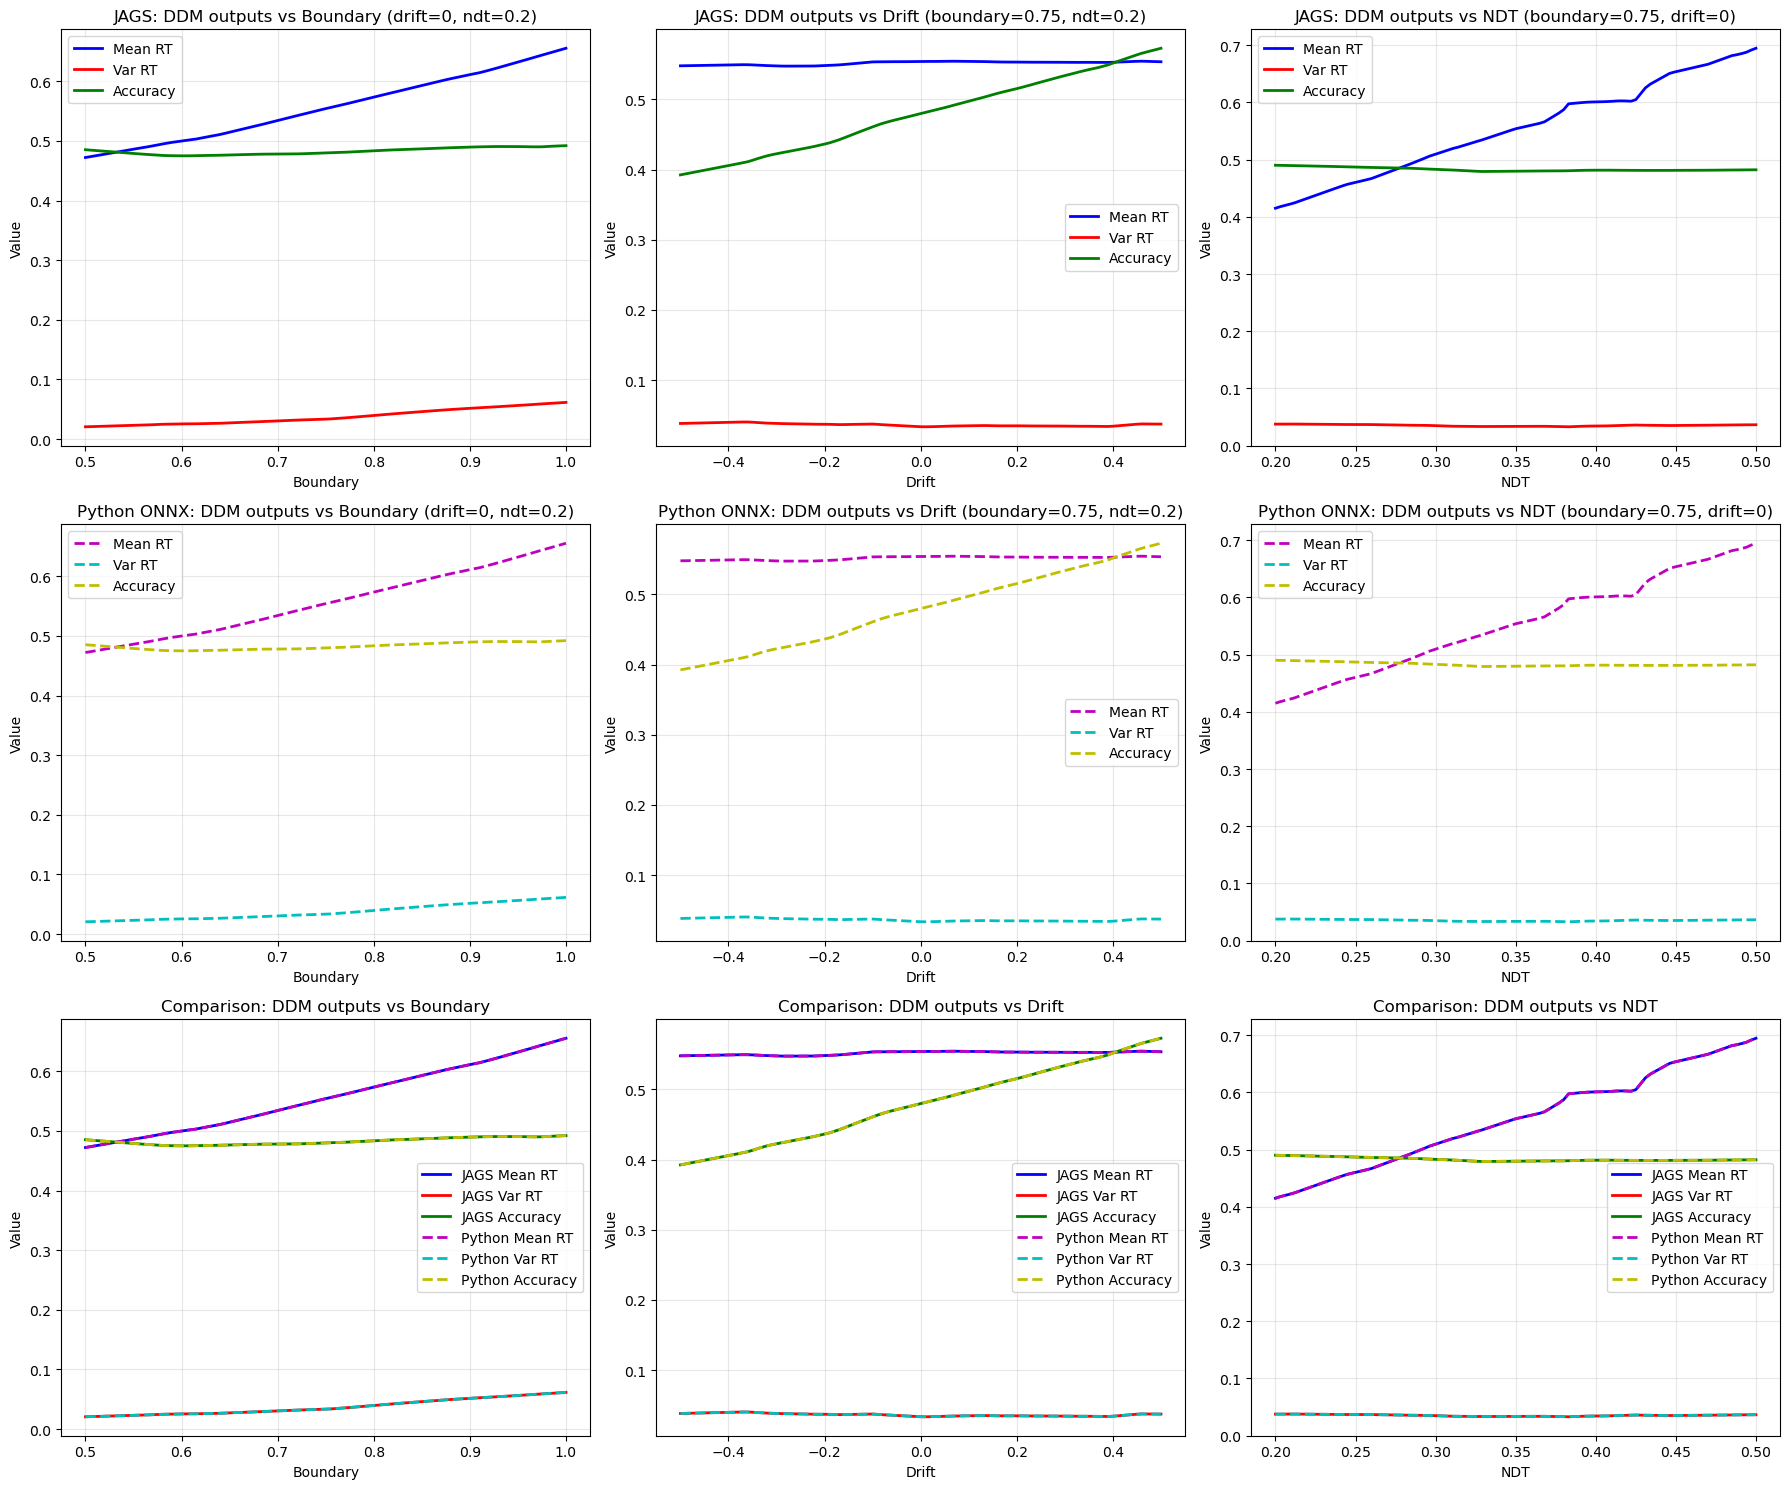


Maximum differences:
Boundary sweep - Mean RT: 4.99e-07, Var RT: 4.93e-08, Acc: 4.92e-07
Drift sweep - Mean RT: 4.96e-07, Var RT: 4.97e-08, Acc: 4.92e-07
NDT sweep - Mean RT: 4.96e-07, Var RT: 5.00e-08, Acc: 5.00e-07
SUCCESS: All results match within machine precision


In [19]:
# Parameter Sweep Analysis
import py2jags
import onnxruntime as ort
import numpy as np
import matplotlib.pyplot as plt
from jnnx import JNNXPackage

# Load the package and ONNX session
pkg = JNNXPackage('/home/jovyan/project/models/ddm.jnnx')
session = ort.InferenceSession(pkg.get_onnx_path())

# Define parameter ranges
drift_values = np.linspace(-0.5, 0.5, 101)
boundary_values = np.linspace(0.5, 1.0, 101)
ndt_values = np.linspace(0.2, 0.5, 101)

# Fixed parameter values for profiling
drift_constant = 0.0
boundary_constant = 0.75
ndt_constant = 0.35

# Initialize arrays for results
jags_meanrt_boundary = np.zeros(101)
jags_varrt_boundary = np.zeros(101)
jags_acc_boundary = np.zeros(101)

jags_meanrt_drift = np.zeros(101)
jags_varrt_drift = np.zeros(101)
jags_acc_drift = np.zeros(101)

jags_meanrt_ndt = np.zeros(101)
jags_varrt_ndt = np.zeros(101)
jags_acc_ndt = np.zeros(101)

python_meanrt_boundary = np.zeros(101)
python_varrt_boundary = np.zeros(101)
python_acc_boundary = np.zeros(101)

python_meanrt_drift = np.zeros(101)
python_varrt_drift = np.zeros(101)
python_acc_drift = np.zeros(101)

python_meanrt_ndt = np.zeros(101)
python_varrt_ndt = np.zeros(101)
python_acc_ndt = np.zeros(101)

print("Evaluating JAGS model...")

# JAGS evaluation: boundary varies, drift=0, ndt=0.2
# The order of inputs is drift, boundary, ndt
# The order of outputs is: 'accuracy', 'mean_rt', 'var_rt'
for i, boundary in enumerate(boundary_values):
    model_string = f'''
    model {{
        result <- {FUNCTION_NAME}({drift_constant}, {boundary}, {ndt_constant})
        dummy ~ dnorm(0, 1)
    }}
    '''
    
    result = py2jags.run_jags(
        model_string=model_string,
        data_dict={'n': 1},
        nchains=1, nsamples=1, nadapt=0, nburnin=0,
        monitorparams=['result'],
        modules=[MODULE_NAME],
        verbosity=0
    )
    
    jags_acc_boundary[i] = result.get_samples('result_1')[0]
    jags_meanrt_boundary[i] = result.get_samples('result_2')[0]
    jags_varrt_boundary[i] = result.get_samples('result_3')[0]

# JAGS evaluation: drift varies, boundary=0.75, ndt=0.2
for i, drift in enumerate(drift_values):
    model_string = f'''
    model {{
        result <- {FUNCTION_NAME}({drift}, {boundary_constant}, {ndt_constant})
        dummy ~ dnorm(0, 1)
    }}
    '''
    
    result = py2jags.run_jags(
        model_string=model_string,
        data_dict={'n': 1},
        nchains=1, nsamples=1, nadapt=0, nburnin=0,
        monitorparams=['result'],
        modules=[MODULE_NAME],
        verbosity=0
    )
    
    jags_acc_drift[i] = result.get_samples('result_1')[0]
    jags_meanrt_drift[i] = result.get_samples('result_2')[0]
    jags_varrt_drift[i] = result.get_samples('result_3')[0]

# JAGS evaluation: ndt varies, boundary=0.75, drift=0
for i, ndt in enumerate(ndt_values):
    model_string = f'''
    model {{
        result <- {FUNCTION_NAME}({drift_constant}, {boundary_constant}, {ndt})
        dummy ~ dnorm(0, 1)
    }}
    '''
    
    result = py2jags.run_jags(
        model_string=model_string,
        data_dict={'n': 1},
        nchains=1, nsamples=1, nadapt=0, nburnin=0,
        monitorparams=['result'],
        modules=[MODULE_NAME],
        verbosity=0
    )
    
    jags_acc_ndt[i] = result.get_samples('result_1')[0]
    jags_meanrt_ndt[i] = result.get_samples('result_2')[0]
    jags_varrt_ndt[i] = result.get_samples('result_3')[0]

print("Evaluating Python ONNX model...")

# Python ONNX evaluation: boundary varies, drift=0, ndt=0.35
# Note: Input order is (drift, boundary, ndt) to match JAGS function signature
for i, boundary in enumerate(boundary_values):
    test_input = np.array([[drift_constant, boundary, ndt_constant]], dtype=np.float32)
    result = session.run(['output'], {'input': test_input})
    python_acc_boundary[i] = result[0][0][0]
    python_meanrt_boundary[i] = result[0][0][1]
    python_varrt_boundary[i] = result[0][0][2]

# Python ONNX evaluation: drift varies, boundary=0.75, ndt=0.35
# Note: Input order is (drift, boundary, ndt) to match JAGS function signature
for i, drift in enumerate(drift_values):
    test_input = np.array([[drift, boundary_constant, ndt_constant]], dtype=np.float32)
    result = session.run(['output'], {'input': test_input})
    python_acc_drift[i] = result[0][0][0]
    python_meanrt_drift[i] = result[0][0][1]
    python_varrt_drift[i] = result[0][0][2]

# Python ONNX evaluation: ndt varies, boundary=0.75, drift=0
# Note: Input order is (drift, boundary, ndt) to match JAGS function signature
for i, ndt in enumerate(ndt_values):
    test_input = np.array([[drift_constant, boundary_constant, ndt]], dtype=np.float32)
    result = session.run(['output'], {'input': test_input})
    python_acc_ndt[i] = result[0][0][0]
    python_meanrt_ndt[i] = result[0][0][1]
    python_varrt_ndt[i] = result[0][0][2]

print("Creating plots...")

# Create plots
fig, axes = plt.subplots(3, 3, figsize=(18, 15))

# Plot 1: DDM outputs vs boundary (JAGS)
axes[0, 0].plot(boundary_values, jags_meanrt_boundary, 'b-', label='Mean RT', linewidth=2)
axes[0, 0].plot(boundary_values, jags_varrt_boundary, 'r-', label='Var RT', linewidth=2)
axes[0, 0].plot(boundary_values, jags_acc_boundary, 'g-', label='Accuracy', linewidth=2)
axes[0, 0].set_xlabel("Boundary")
axes[0, 0].set_ylabel("Value")
axes[0, 0].set_title("JAGS: DDM outputs vs Boundary (drift=0, ndt=0.2)")
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: DDM outputs vs drift (JAGS)
axes[0, 1].plot(drift_values, jags_meanrt_drift, 'b-', label='Mean RT', linewidth=2)
axes[0, 1].plot(drift_values, jags_varrt_drift, 'r-', label='Var RT', linewidth=2)
axes[0, 1].plot(drift_values, jags_acc_drift, 'g-', label='Accuracy', linewidth=2)
axes[0, 1].set_xlabel("Drift")
axes[0, 1].set_ylabel("Value")
axes[0, 1].set_title("JAGS: DDM outputs vs Drift (boundary=0.75, ndt=0.2)")
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: DDM outputs vs ndt (JAGS)
axes[0, 2].plot(ndt_values, jags_meanrt_ndt, 'b-', label='Mean RT', linewidth=2)
axes[0, 2].plot(ndt_values, jags_varrt_ndt, 'r-', label='Var RT', linewidth=2)
axes[0, 2].plot(ndt_values, jags_acc_ndt, 'g-', label='Accuracy', linewidth=2)
axes[0, 2].set_xlabel("NDT")
axes[0, 2].set_ylabel("Value")
axes[0, 2].set_title("JAGS: DDM outputs vs NDT (boundary=0.75, drift=0)")
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# Plot 4: DDM outputs vs boundary (Python)
axes[1, 0].plot(boundary_values, python_meanrt_boundary, 'm--', label='Mean RT', linewidth=2)
axes[1, 0].plot(boundary_values, python_varrt_boundary, 'c--', label='Var RT', linewidth=2)
axes[1, 0].plot(boundary_values, python_acc_boundary, 'y--', label='Accuracy', linewidth=2)
axes[1, 0].set_xlabel("Boundary")
axes[1, 0].set_ylabel("Value")
axes[1, 0].set_title("Python ONNX: DDM outputs vs Boundary (drift=0, ndt=0.2)")
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Plot 5: DDM outputs vs drift (Python)
axes[1, 1].plot(drift_values, python_meanrt_drift, 'm--', label='Mean RT', linewidth=2)
axes[1, 1].plot(drift_values, python_varrt_drift, 'c--', label='Var RT', linewidth=2)
axes[1, 1].plot(drift_values, python_acc_drift, 'y--', label='Accuracy', linewidth=2)
axes[1, 1].set_xlabel("Drift")
axes[1, 1].set_ylabel("Value")
axes[1, 1].set_title("Python ONNX: DDM outputs vs Drift (boundary=0.75, ndt=0.2)")
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# Plot 6: DDM outputs vs ndt (Python)
axes[1, 2].plot(ndt_values, python_meanrt_ndt, 'm--', label='Mean RT', linewidth=2)
axes[1, 2].plot(ndt_values, python_varrt_ndt, 'c--', label='Var RT', linewidth=2)
axes[1, 2].plot(ndt_values, python_acc_ndt, 'y--', label='Accuracy', linewidth=2)
axes[1, 2].set_xlabel("NDT")
axes[1, 2].set_ylabel("Value")
axes[1, 2].set_title("Python ONNX: DDM outputs vs NDT (boundary=0.75, drift=0)")
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)

# Overlay comparison plots
axes[2, 0].plot(boundary_values, jags_meanrt_boundary, 'b-', label='JAGS Mean RT', linewidth=2)
axes[2, 0].plot(boundary_values, jags_varrt_boundary, 'r-', label='JAGS Var RT', linewidth=2)
axes[2, 0].plot(boundary_values, jags_acc_boundary, 'g-', label='JAGS Accuracy', linewidth=2)
axes[2, 0].plot(boundary_values, python_meanrt_boundary, 'm--', label='Python Mean RT', linewidth=2)
axes[2, 0].plot(boundary_values, python_varrt_boundary, 'c--', label='Python Var RT', linewidth=2)
axes[2, 0].plot(boundary_values, python_acc_boundary, 'y--', label='Python Accuracy', linewidth=2)
axes[2, 0].set_xlabel("Boundary")
axes[2, 0].set_ylabel("Value")
axes[2, 0].set_title("Comparison: DDM outputs vs Boundary")
axes[2, 0].legend()
axes[2, 0].grid(True, alpha=0.3)

axes[2, 1].plot(drift_values, jags_meanrt_drift, 'b-', label='JAGS Mean RT', linewidth=2)
axes[2, 1].plot(drift_values, jags_varrt_drift, 'r-', label='JAGS Var RT', linewidth=2)
axes[2, 1].plot(drift_values, jags_acc_drift, 'g-', label='JAGS Accuracy', linewidth=2)
axes[2, 1].plot(drift_values, python_meanrt_drift, 'm--', label='Python Mean RT', linewidth=2)
axes[2, 1].plot(drift_values, python_varrt_drift, 'c--', label='Python Var RT', linewidth=2)
axes[2, 1].plot(drift_values, python_acc_drift, 'y--', label='Python Accuracy', linewidth=2)
axes[2, 1].set_xlabel("Drift")
axes[2, 1].set_ylabel("Value")
axes[2, 1].set_title("Comparison: DDM outputs vs Drift")
axes[2, 1].legend()
axes[2, 1].grid(True, alpha=0.3)

axes[2, 2].plot(ndt_values, jags_meanrt_ndt, 'b-', label='JAGS Mean RT', linewidth=2)
axes[2, 2].plot(ndt_values, jags_varrt_ndt, 'r-', label='JAGS Var RT', linewidth=2)
axes[2, 2].plot(ndt_values, jags_acc_ndt, 'g-', label='JAGS Accuracy', linewidth=2)
axes[2, 2].plot(ndt_values, python_meanrt_ndt, 'm--', label='Python Mean RT', linewidth=2)
axes[2, 2].plot(ndt_values, python_varrt_ndt, 'c--', label='Python Var RT', linewidth=2)
axes[2, 2].plot(ndt_values, python_acc_ndt, 'y--', label='Python Accuracy', linewidth=2)
axes[2, 2].set_xlabel("NDT")
axes[2, 2].set_ylabel("Value")
axes[2, 2].set_title("Comparison: DDM outputs vs NDT")
axes[2, 2].legend()
axes[2, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calculate and display differences
max_diff_boundary_meanrt = np.max(np.abs(jags_meanrt_boundary - python_meanrt_boundary))
max_diff_boundary_varrt = np.max(np.abs(jags_varrt_boundary - python_varrt_boundary))
max_diff_boundary_acc = np.max(np.abs(jags_acc_boundary - python_acc_boundary))

max_diff_drift_meanrt = np.max(np.abs(jags_meanrt_drift - python_meanrt_drift))
max_diff_drift_varrt = np.max(np.abs(jags_varrt_drift - python_varrt_drift))
max_diff_drift_acc = np.max(np.abs(jags_acc_drift - python_acc_drift))

max_diff_ndt_meanrt = np.max(np.abs(jags_meanrt_ndt - python_meanrt_ndt))
max_diff_ndt_varrt = np.max(np.abs(jags_varrt_ndt - python_varrt_ndt))
max_diff_ndt_acc = np.max(np.abs(jags_acc_ndt - python_acc_ndt))

print(f"\nMaximum differences:")
print(f"Boundary sweep - Mean RT: {max_diff_boundary_meanrt:.2e}, Var RT: {max_diff_boundary_varrt:.2e}, Acc: {max_diff_boundary_acc:.2e}")
print(f"Drift sweep - Mean RT: {max_diff_drift_meanrt:.2e}, Var RT: {max_diff_drift_varrt:.2e}, Acc: {max_diff_drift_acc:.2e}")
print(f"NDT sweep - Mean RT: {max_diff_ndt_meanrt:.2e}, Var RT: {max_diff_ndt_varrt:.2e}, Acc: {max_diff_ndt_acc:.2e}")

all_diffs = [max_diff_boundary_meanrt, max_diff_boundary_varrt, max_diff_boundary_acc,
             max_diff_drift_meanrt, max_diff_drift_varrt, max_diff_drift_acc,
             max_diff_ndt_meanrt, max_diff_ndt_varrt, max_diff_ndt_acc]

if max(all_diffs) < 1e-6:
    print("SUCCESS: All results match within machine precision")
else:
    print("WARNING: Some differences exceed machine precision")


## Expected Results

Both outputs should match within machine precision (differences < 1e-6).